<a href="https://colab.research.google.com/github/kimcheese23/Data-analytics/blob/main/Code/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/PTDL'

Mounted at /content/drive


# 1. File và thư viện

In [3]:
# Thêm các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Dataset: https://www.kaggle.com/datasets/divyansh22/online-gaming-anxiety-data/code

In [4]:
df_raw = pd.read_csv('/content/drive/MyDrive/PTDL/GamingStudy_data.csv', encoding='latin1')
df_raw.head(5).T

,0,1,2,3,4
S. No.,1,2,3,4,5
Timestamp,42052.00437,42052.0068,42052.0386,42052.06804,42052.08948
GAD1,0,1,0,0,2
GAD2,0,2,2,0,1
GAD3,0,2,2,0,2
GAD4,0,2,0,0,2
GAD5,1,0,0,0,2
GAD6,0,1,3,0,3
GAD7,0,0,1,0,2
GADE,Not difficult at all,Somewhat difficult,Not difficult at all,Not difficult at all,Very difficult


# 2. Tiền xử lý dữ liệu

Tìm hiểu dữ liệu

In [5]:
df = df_raw.copy()
print(f'Dữ liệu có {df.shape[0]} dòng quan sát và {df.shape[1]} cột thuộc tính.')

Dữ liệu có 13464 dòng quan sát và 55 cột thuộc tính.


In [6]:
df.columns

Index(['S. No.', 'Timestamp', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6',
       'GAD7', 'GADE', 'SWL1', 'SWL2', 'SWL3', 'SWL4', 'SWL5', 'Game',
       'Platform', 'Hours', 'earnings', 'whyplay', 'League', 'highestleague',
       'streams', 'SPIN1', 'SPIN2', 'SPIN3', 'SPIN4', 'SPIN5', 'SPIN6',
       'SPIN7', 'SPIN8', 'SPIN9', 'SPIN10', 'SPIN11', 'SPIN12', 'SPIN13',
       'SPIN14', 'SPIN15', 'SPIN16', 'SPIN17', 'Narcissism', 'Gender', 'Age',
       'Work', 'Degree', 'Birthplace', 'Residence', 'Reference', 'Playstyle',
       'accept', 'GAD_T', 'SWL_T', 'SPIN_T', 'Residence_ISO3',
       'Birthplace_ISO3'],
      dtype='object')

In [7]:
print('Số giá trị bị thiếu trong tập dữ liệu: ', df.isnull().sum().sum())
print('Số dòng trùng: ', df.duplicated().sum())

Số giá trị bị thiếu trong tập dữ liệu:  21709
Số dòng trùng:  0


In [8]:
def value_check(dataframe):
    dataframe_check = pd.DataFrame({
        'Count': dataframe.count(),
        'Unique': dataframe.nunique(),
        'Null': dataframe.isnull().sum(),
        '%Null': (dataframe.isnull().sum() / len(dataframe)) * 100,
        'DType': dataframe.dtypes.values
    })
    dataframe_check['%Null'] = dataframe_check['%Null'].map('{:.2f}%'.format)
    return dataframe_check

In [9]:
value_check(df)

,Count,Unique,Null,%Null,DType
S. No.,13464,13464,0,0.00%,int64
Timestamp,13464,11734,0,0.00%,float64
GAD1,13464,4,0,0.00%,int64
GAD2,13464,4,0,0.00%,int64
GAD3,13464,4,0,0.00%,int64
GAD4,13464,4,0,0.00%,int64
GAD5,13464,4,0,0.00%,int64
GAD6,13464,4,0,0.00%,int64
GAD7,13464,4,0,0.00%,int64
GADE,12815,4,649,4.82%,object


In [10]:
print('\nThống kê mô tả các biến định lượng:')
df.describe().style.format('{:.2f}')


Thống kê mô tả các biến định lượng:


,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,SWL1,SWL2,SWL3,SWL4,SWL5,Hours,highestleague,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Age,GAD_T,SWL_T,SPIN_T
count,13464.00,13464.00,13464.00,13464.00,13464.00,13464.00,13464.00,13464.00,13464.00,13464.00,13464.00,13464.00,13464.00,13464.00,13434.00,0.00,13364.00,13340.00,13310.00,13324.00,13305.00,13298.00,13308.00,13326.00,13320.00,13306.00,13304.00,13277.00,13296.00,13277.00,13308.00,13317.00,13317.00,13289.00,13441.00,13464.00,13464.00,13464.00,12814.00
mean,7096.84,42054.84,0.86,0.67,0.97,0.72,0.49,0.91,0.59,3.72,4.60,4.35,3.76,3.36,22.25,nan,11.23,0.86,1.21,1.10,1.68,1.25,1.35,1.05,1.41,1.57,0.92,1.83,0.89,0.54,1.25,1.41,0.62,0.94,2.03,20.93,5.21,19.79,19.85
std,4114.48,0.27,0.93,0.92,0.98,0.92,0.84,0.93,0.89,1.74,1.70,1.81,1.82,1.92,70.28,nan,78.55,0.91,1.14,1.16,1.23,1.22,1.28,1.22,1.37,1.38,1.13,1.49,1.16,0.94,1.21,1.35,0.96,1.18,1.06,3.30,4.71,7.23,13.47
min,1.00,42052.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,nan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,18.00,0.00,5.00,0.00
25%,3532.75,42054.72,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,3.00,3.00,2.00,2.00,12.00,nan,4.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,18.00,2.00,14.00,9.00
50%,7087.50,42054.80,1.00,0.00,1.00,0.00,0.00,1.00,0.00,4.00,5.00,5.00,4.00,3.00,20.00,nan,8.00,1.00,1.00,1.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,0.00,0.00,1.00,1.00,0.00,0.00,2.00,20.00,4.00,20.00,17.00
75%,10654.25,42054.93,1.00,1.00,2.00,1.00,1.00,1.00,1.00,5.00,6.00,6.00,5.00,5.00,28.00,nan,15.00,1.00,2.00,2.00,3.00,2.00,2.00,2.00,2.00,3.00,1.00,3.00,1.00,1.00,2.00,2.00,1.00,2.00,3.00,22.00,8.00,26.00,28.00
max,14250.00,42058.36,3.00,3.00,3.00,3.00,3.00,3.00,3.00,7.00,7.00,7.00,7.00,7.00,8000.00,nan,9001.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,5.00,63.00,21.00,35.00,68.00


In [11]:
print('\nThống kê mô tả các biến kiểu object:')
df.describe(include=['O'])


Thống kê mô tả các biến kiểu object:


,GADE,Game,Platform,earnings,whyplay,League,Gender,Work,Degree,Birthplace,Residence,Reference,Playstyle,accept,Residence_ISO3,Birthplace_ISO3
count,12815,13464,13464,13464,13464,11612,13464,13426,11887,13464,13464,13449,13464,13050,13354,13343
unique,4,11,3,314,407,1454,3,4,4,126,109,4,298,1,107,124
top,Not difficult at all,League of Legends,PC,I play for fun,having fun,Gold,Male,Student at college / university,High school diploma (or equivalent),USA,USA,Reddit,Multiplayer - online - with real life friends,Accept,USA,USA
freq,6236,11314,13219,12112,5289,970,12699,7073,8560,4261,4569,13324,5564,13050,4569,4261


Xử lý các cột không cần thiết trong phân tích


*   Bỏ cột dữ liệu trống hoàn toàn highestleague
*   Bỏ cột không liên quan trong phân tích gồm: S. No, Timestamp, Birthplace, Birthplace_ISO3, Residence, Reference, accept, League



In [41]:
cols_to_drop = ['S. No.', 'Timestamp', 'highestleague', 'Birthplace', 'Birthplace_ISO3', 'Residence', 'Reference', 'accept', 'League']
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)
df.shape

(13330, 47)

2.1 Xử lí giá trị null

In [13]:
df['Hours'] = df['Hours'].fillna(df['Hours'].median())

In [14]:
df['Narcissism'] = df['Narcissism'].fillna(df['Narcissism'].median())

In [15]:
df['streams'] = df['streams'].fillna(0)

In [16]:
df['Degree'] = df['Degree'].fillna('Other')

In [17]:
df['Work'] = df['Work'].fillna('Other')

In [ ]:
df['Residence_ISO3'] = df['Residence_ISO3'].fillna('Other')

In [18]:
condition = [
    (df['GAD_T'] >= 0) & (df['GAD_T'] <= 4),
    (df['GAD_T'] >= 5) & (df['GAD_T'] <= 9),
    (df['GAD_T'] >= 10) & (df['GAD_T'] <= 14),
    (df['GAD_T'] >= 15) & (df['GAD_T'] <= 21)
]
choice = [
    'Not difficult at all',
    'Somewhat difficult',
    'Very difficult',
    'Extremely difficult'
]
mapped_gade = np.select(condition, choice, default='')
df['GADE'] = df['GADE'].fillna(pd.Series(mapped_gade, index=df.index))

In [19]:
spin_cols = []
for i in range (1, 18):
    spin_cols.append(f'SPIN{i}')
df = df.dropna(subset=spin_cols, thresh=14)

In [20]:
df[spin_cols] = df[spin_cols].apply(lambda row: row.fillna(row.median()), axis=1)

In [21]:
# Tính lại SPIN_T
df['SPIN_T'] = df[spin_cols].sum(axis=1)
#df = df.drop(columns=spin_cols)

In [22]:
value_check(df)

,Count,Unique,Null,%Null,DType
GAD1,13338,4,0,0.00%,int64
GAD2,13338,4,0,0.00%,int64
GAD3,13338,4,0,0.00%,int64
GAD4,13338,4,0,0.00%,int64
GAD5,13338,4,0,0.00%,int64
GAD6,13338,4,0,0.00%,int64
GAD7,13338,4,0,0.00%,int64
GADE,13338,4,0,0.00%,object
SWL1,13338,7,0,0.00%,int64
SWL2,13338,7,0,0.00%,int64


2.2 Xử lý giá trị outlier

In [23]:
df.drop(df[df.Hours >= 140].index, inplace=True)
df.drop(df[df.streams >= 140].index, inplace=True)

2.3 Chuẩn hóa dữ liệu

In [24]:
# chuẩn hóa dữ liệu của cột whyplay
def whyplay_clean(text):
    text = str(text).lower()
    if "none of the above" in text:
        return "Other"
    if "all of the above minus relaxing" in text:
        return "Having_Fun, Improving, Winning"
    if "a, b, and d" in text:
        return "Having_Fun, Improving, Winning"
    if "first two" in text:
        return "Improving, Winning"
    if "last 3" in text or "last three" in text or "three last" in text:
        return "Having Fun, Improving, Relaxing"

    all_keywords = ["all", "mix", "both", "depend", "vary", "a b c", "4 of", "4 point", "4 thing", "4 above", "everything", "alternating", "mixture", "former", "options"]
    if any(kw in text for kw in all_keywords):
        return "Having Fun, Improving, Relaxing, Winning"

    found = set()

    if any(kw in text for kw in ["win", "compet", "conpeting", "kda", "crush", "dumpster", "top", "board", "beat", "destroy", "losing", "prove", "ranked"]):
        found.add("Winning")
    if any(kw in text for kw in ["improv", "learn", "better", "skill", "challeng", "cognition", "strategiz", "mental stimulation", "metagame", "well", "performing", "good"]):
        found.add("Improving")
    if any(kw in text for kw in ["relax", "distract", "forget", "escape", "escaping", "waste", "wasting", "kill", "bored", "mind", "stress", "tension", "hide", "trouble", "reality", "real life", "numb", "shortcomings", "depression", "disorder", "pain", "worry", "pass", "occupied", "occupation", "doing something", "something to do", "tv", "habit", "focus off"]):
        found.add("Relaxing")
    if any(kw in text for kw in ["fun", "enjoy", "experience", "orgasms", "aram", "teemo", "sea anemones", "satisfaction", "playing the game"]):
        found.add("Having Fun")
    if any(kw in text for kw in ["friend", "social", "team", "together", "helping", "people", "cooperat"]):
        found.add("Social")
    if len(found) > 0:
        return ", ".join(sorted(list(found)))
    else:
        return "Other"

In [25]:
df['whyplay_final'] = df['whyplay'].apply(whyplay_clean)

In [39]:
df.shape

(13330, 48)

# 3. Khám phá dữ liệu (EDA)

In [26]:
print('\nPhân bố số lượng theo lí do chơi game:')
reason_counts = df['whyplay_final'].value_counts().reset_index()
reason_counts.columns = ['Lý do', 'Số lượng']
pd.set_option('display.max_rows', None)
print(reason_counts)


Phân bố số lượng theo lí do chơi game:
                                       Lý do  Số lượng
0                                 Having Fun      5262
1                                  Improving      4894
2                                    Winning      2070
3                                   Relaxing       699
4   Having Fun, Improving, Relaxing, Winning       175
5                      Having Fun, Improving        53
6                        Having Fun, Winning        44
7                         Improving, Winning        28
8             Having Fun, Improving, Winning        19
9                                     Social        17
10           Having Fun, Improving, Relaxing        12
11                                     Other        11
12                      Having Fun, Relaxing        11
13                       Improving, Relaxing         6
14                           Social, Winning         6
15                         Relaxing, Winning         3
16              Improving

In [37]:
df['whyplay'].unique()

array(['having fun', 'improving', 'relaxing', 'winning',
       'improving, having fun', 'All',
       "I play it as I watch TV or movies.  I've gone through many a Netflix binge with Isaac.",
       'Reaching goal i.e. GM ',
       'Improving AND having fun (kinda wish I could pick more than one)',
       'all of the above', 'passing the time', 'having fun and improving',
       'Forgetting troubles', 'All of them', 'Being with friends',
       'getting good loot', 'have fun and win',
       'Winning 55% improving 45%', 'Wasting time',
       'talking to irl friends', 'Forgetting about my drug addiction',
       'Having fun and improving at the same time',
       'Improving and having fun.', 'improving while having fun',
       'All of the above!', 'socializing', 'all above', 'playing well',
       'winning + having fun', 'having a distraction',
       'the three last: improving, relaxing and having fun',
       'winning and improving',
       'depends, wwinning in rankeds, fun and re

In [33]:
var_count = ['Gender', 'Platform', 'Game', 'Work', 'Degree', 'Residence_ISO3']
for i in var_count:
    print(df[i].value_counts())
    print('*'*40)

Gender
Male      12572
Female      709
Other        49
Name: count, dtype: int64
****************************************
Platform
PC                         13092
Console (PS, Xbox, ...)      217
Smartphone / Tablet           21
Name: count, dtype: int64
****************************************
Game
League of Legends      11203
Other                   1009
Starcraft 2              343
Counter Strike           314
World of Warcraft        151
Hearthstone               98
Diablo 3                  89
Heroes of the Storm       41
Guild Wars 2              37
Skyrim                    27
Destiny                   18
Name: count, dtype: int64
****************************************
Work
Student at college / university    7012
Employed                           2716
Student at school                  2189
Unemployed / between jobs          1379
Other                                34
Name: count, dtype: int64
****************************************
Degree
High school diploma (or equivalen

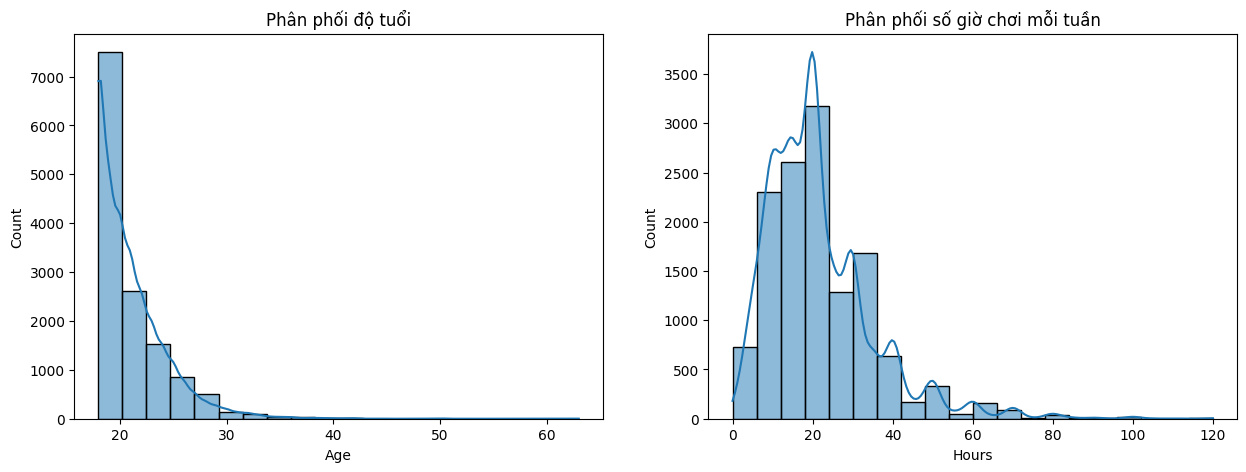

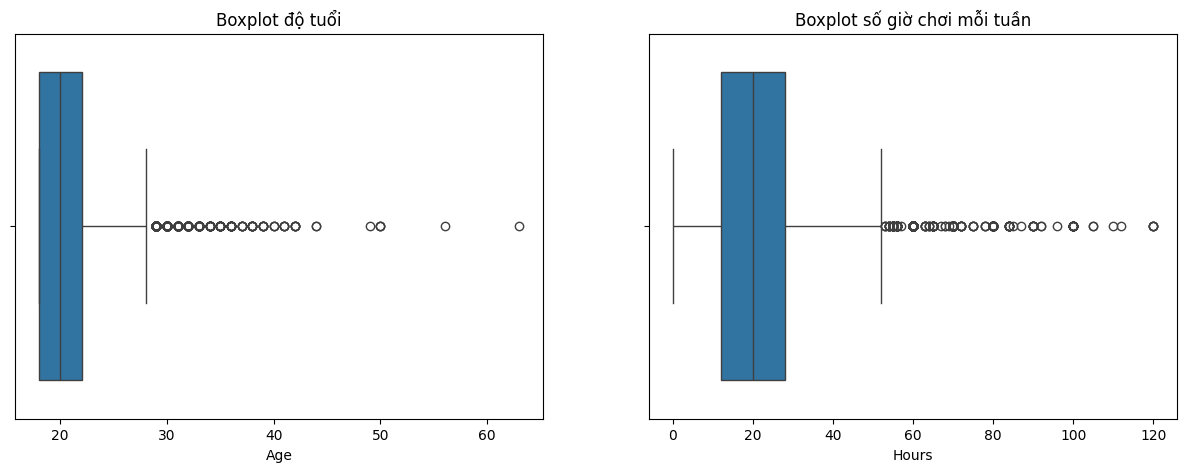

In [29]:
# Vẽ biểu đồ phân phối
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Age'].dropna(), bins=20, ax=axes[0], kde=True)
axes[0].set_title('Phân phối độ tuổi')
sns.histplot(df['Hours'].dropna(), bins=20, ax=axes[1], kde=True)
axes[1].set_title('Phân phối số giờ chơi mỗi tuần')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['Age'], ax=axes[0])
axes[0].set_title('Boxplot độ tuổi')
sns.boxplot(x=df['Hours'], ax=axes[1])
axes[1].set_title('Boxplot số giờ chơi mỗi tuần')
plt.show()

In [30]:
df.head()

,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,...,Gender,Age,Work,Degree,Playstyle,GAD_T,SWL_T,SPIN_T,Residence_ISO3,whyplay_final
0,0,0,0,0,1,0,0,Not difficult at all,3,5,...,Male,25,Unemployed / between jobs,Bachelor (or equivalent),Singleplayer,1,23,5.0,USA,Having Fun
1,1,2,2,2,0,1,0,Somewhat difficult,3,5,...,Male,41,Unemployed / between jobs,Bachelor (or equivalent),Multiplayer - online - with strangers,8,16,33.0,USA,Having Fun
2,0,2,2,0,0,3,1,Not difficult at all,2,6,...,Female,32,Employed,Bachelor (or equivalent),Singleplayer,8,17,31.0,DEU,Having Fun
3,0,0,0,0,0,0,0,Not difficult at all,2,5,...,Male,28,Employed,Bachelor (or equivalent),Multiplayer - online - with online acquaintanc...,0,17,11.0,USA,Improving
4,2,1,2,2,2,3,2,Very difficult,2,2,...,Male,19,Employed,High school diploma (or equivalent),Multiplayer - online - with strangers,14,14,13.0,KOR,Having Fun


In [31]:
df.shape

(13330, 48)

# 4. Lưu file

In [32]:
#df.to_csv(folder + '/GamingStudy_data_clean.csv', index = False)